# Groundwater + GDP model inputs

保存済みの全240,000 Spatial OOFセルについて、モデルが実際に使用した説明変数を
1°四角グリッドへ集約した全球可視化シートです。

モデル学習・OOF・SHAP計算は再実行しません。

/work/tsuda/miniconda3/envs/research/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


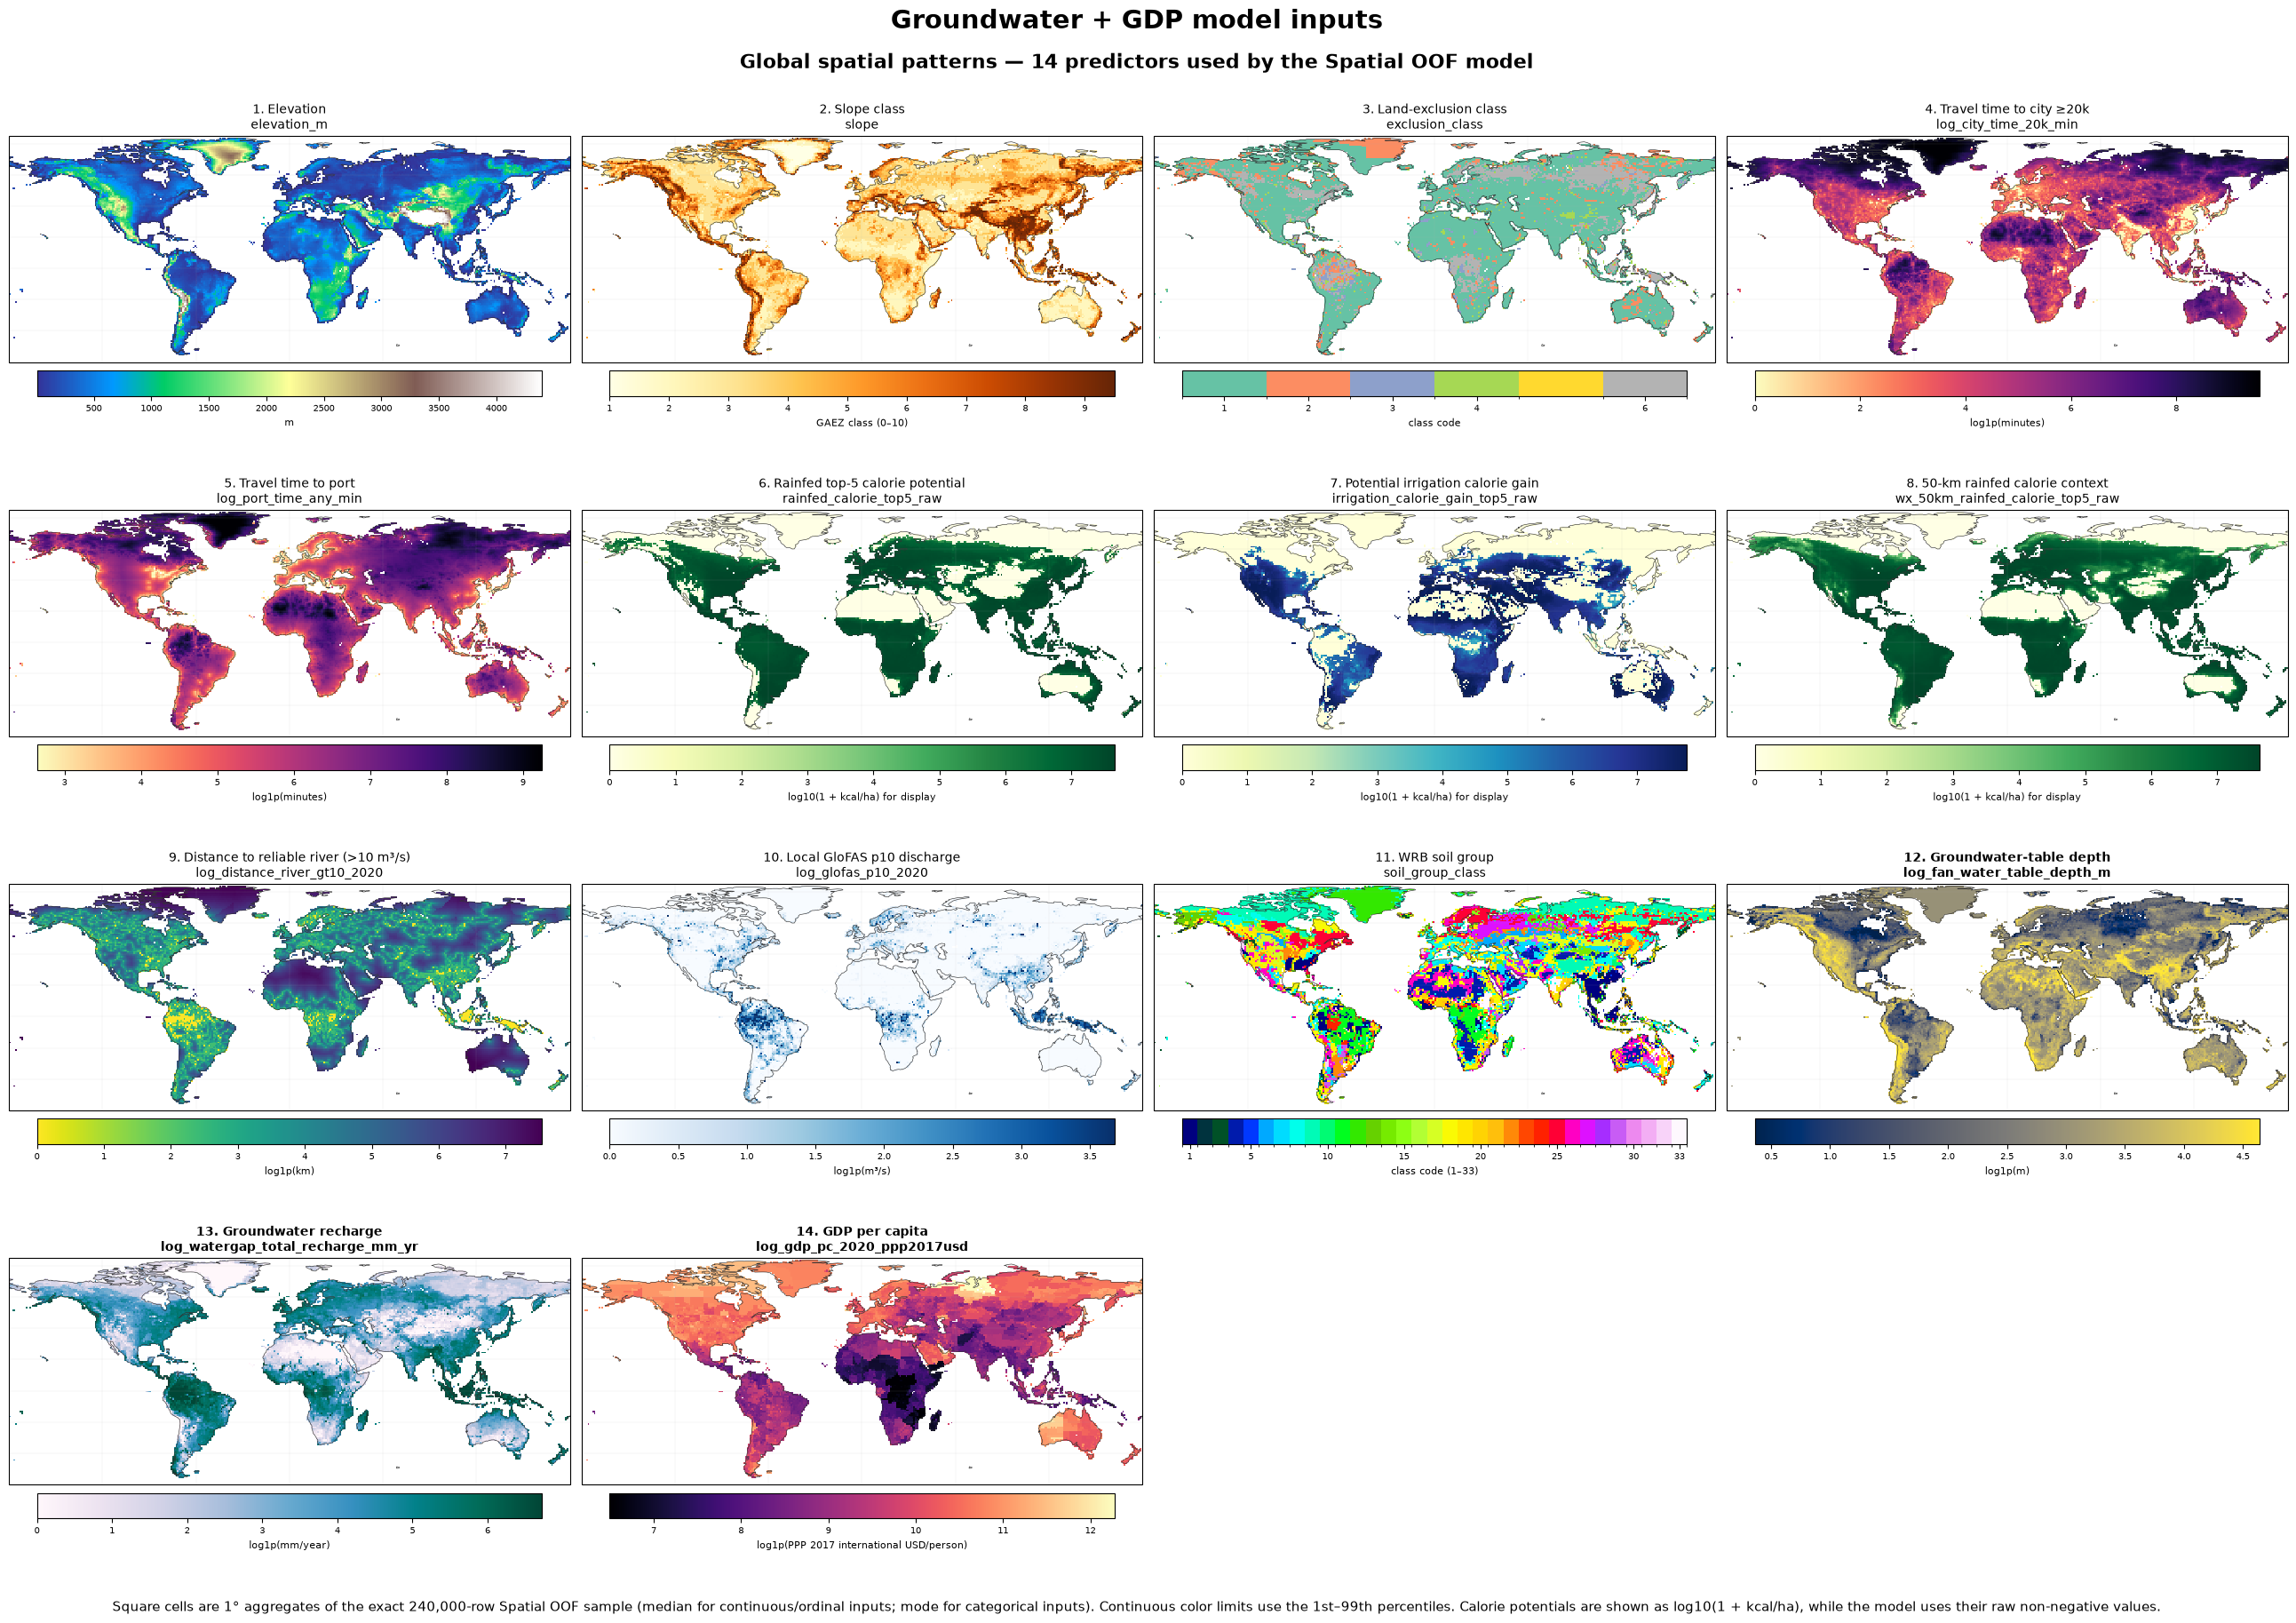

Source: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_gdp_target2020/integrated_final_feature_dependence_bg32_perm32/integrated_feature_values_and_shapley_by_cell.csv.gz
Rows: 240,000
Predictors: 14
Saved figure: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_gdp_target2020/model_input_variable_maps.png
Saved catalog: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_gdp_target2020/model_input_variable_map_catalog.csv
Saved summary: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_gdp_target2020/model_input_variable_map_summary.csv


,order,feature,label,group,unit
0,1,elevation_m,Elevation,Land and soil,m
1,2,slope,Slope class,Land and soil,GAEZ class (0–10)
2,3,exclusion_class,Land-exclusion class,Land and soil,class code
3,4,log_city_time_20k_min,Travel time to city ≥20k,Market access,log1p(minutes)
4,5,log_port_time_any_min,Travel time to port,Market access,log1p(minutes)
5,6,rainfed_calorie_top5_raw,Rainfed top-5 calorie potential,Climate and water,log10(1 + kcal/ha) for display
6,7,irrigation_calorie_gain_top5_raw,Potential irrigation calorie gain,Climate and water,log10(1 + kcal/ha) for display
7,8,wx_50km_rainfed_calorie_top5_raw,50-km rainfed calorie context,Climate and water,log10(1 + kcal/ha) for display
8,9,log_distance_river_gt10_2020,Distance to reliable river (>10 m³/s),Climate and water,log1p(km)
9,10,log_glofas_p10_2020,Local GloFAS p10 discharge,Climate and water,log1p(m³/s)


,order,feature,label,group,unit,n_rows,n_missing,min,p01,median,p99,max,map_vmin,map_vmax
0,1,elevation_m,Elevation,Land and soil,m,240000,0,-251.000000,7.000000,3.860000e+02,4.423000e+03,6.316000e+03,5.500000,4396.090000
1,2,slope,Slope class,Land and soil,GAEZ class (0–10),240000,0,1.000000,1.000000,4.000000e+00,1.000000e+01,1.000000e+01,1.000000,9.500000
2,3,exclusion_class,Land-exclusion class,Land and soil,class code,240000,0,1.000000,1.000000,1.000000e+00,6.000000e+00,6.000000e+00,1.000000,6.000000
3,4,log_city_time_20k_min,Travel time to city ≥20k,Market access,log1p(minutes),240000,0,0.000000,0.000000,4.927254e+00,9.548384e+00,1.013054e+01,0.000000,9.582986
4,5,log_port_time_any_min,Travel time to port,Market access,log1p(minutes),240000,0,0.000000,2.639057,6.486161e+00,9.182457e+00,9.928668e+00,2.639057,9.246801
5,6,rainfed_calorie_top5_raw,Rainfed top-5 calorie potential,Climate and water,log10(1 + kcal/ha) for display,240000,0,0.000000,0.000000,1.303822e+07,4.569821e+07,5.612009e+07,0.000000,7.652013
6,7,irrigation_calorie_gain_top5_raw,Potential irrigation calorie gain,Climate and water,log10(1 + kcal/ha) for display,240000,0,0.000000,0.000000,5.649100e+04,5.853772e+07,6.643168e+07,0.000000,7.764139
7,8,wx_50km_rainfed_calorie_top5_raw,50-km rainfed calorie context,Climate and water,log10(1 + kcal/ha) for display,240000,0,0.000000,0.000000,1.215436e+07,4.465114e+07,5.250200e+07,0.000000,7.640395
8,9,log_distance_river_gt10_2020,Distance to reliable river (>10 m³/s),Climate and water,log1p(km),240000,0,0.000000,0.000000,4.294623e+00,7.493597e+00,8.903147e+00,0.000000,7.540107
9,10,log_glofas_p10_2020,Local GloFAS p10 discharge,Climate and water,log1p(m³/s),240000,0,0.000000,0.000000,2.316706e-02,6.282801e+00,1.135135e+01,0.000000,3.679090


5907

In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm

RESULT_DIR = Path(r"/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_gdp_target2020")
SOURCE_PATH = (
    RESULT_DIR
    / "integrated_final_feature_dependence_bg32_perm32"
    / "integrated_feature_values_and_shapley_by_cell.csv.gz"
)
FIGURE_PATH = RESULT_DIR / "model_input_variable_maps.png"
CATALOG_PATH = RESULT_DIR / "model_input_variable_map_catalog.csv"
SUMMARY_PATH = RESULT_DIR / "model_input_variable_map_summary.csv"

FEATURES = [{'order': 1, 'feature': 'elevation_m', 'label': 'Elevation', 'group': 'Land and soil', 'type': 'continuous', 'unit': 'm', 'display': 'identity', 'cmap': 'terrain'}, {'order': 2, 'feature': 'slope', 'label': 'Slope class', 'group': 'Land and soil', 'type': 'ordinal', 'unit': 'GAEZ class (0–10)', 'display': 'identity', 'cmap': 'YlOrBr'}, {'order': 3, 'feature': 'exclusion_class', 'label': 'Land-exclusion class', 'group': 'Land and soil', 'type': 'categorical', 'unit': 'class code', 'display': 'identity', 'cmap': 'Set2'}, {'order': 4, 'feature': 'log_city_time_20k_min', 'label': 'Travel time to city ≥20k', 'group': 'Market access', 'type': 'continuous', 'unit': 'log1p(minutes)', 'display': 'identity', 'cmap': 'magma_r'}, {'order': 5, 'feature': 'log_port_time_any_min', 'label': 'Travel time to port', 'group': 'Market access', 'type': 'continuous', 'unit': 'log1p(minutes)', 'display': 'identity', 'cmap': 'magma_r'}, {'order': 6, 'feature': 'rainfed_calorie_top5_raw', 'label': 'Rainfed top-5 calorie potential', 'group': 'Climate and water', 'type': 'continuous', 'unit': 'log10(1 + kcal/ha) for display', 'display': 'log10p', 'cmap': 'YlGn'}, {'order': 7, 'feature': 'irrigation_calorie_gain_top5_raw', 'label': 'Potential irrigation calorie gain', 'group': 'Climate and water', 'type': 'continuous', 'unit': 'log10(1 + kcal/ha) for display', 'display': 'log10p', 'cmap': 'YlGnBu'}, {'order': 8, 'feature': 'wx_50km_rainfed_calorie_top5_raw', 'label': '50-km rainfed calorie context', 'group': 'Climate and water', 'type': 'continuous', 'unit': 'log10(1 + kcal/ha) for display', 'display': 'log10p', 'cmap': 'YlGn'}, {'order': 9, 'feature': 'log_distance_river_gt10_2020', 'label': 'Distance to reliable river (>10 m³/s)', 'group': 'Climate and water', 'type': 'continuous', 'unit': 'log1p(km)', 'display': 'identity', 'cmap': 'viridis_r'}, {'order': 10, 'feature': 'log_glofas_p10_2020', 'label': 'Local GloFAS p10 discharge', 'group': 'Climate and water', 'type': 'continuous', 'unit': 'log1p(m³/s)', 'display': 'identity', 'cmap': 'Blues'}, {'order': 11, 'feature': 'soil_group_class', 'label': 'WRB soil group', 'group': 'Land and soil', 'type': 'categorical', 'unit': 'class code (1–33)', 'display': 'identity', 'cmap': 'gist_ncar'}, {'order': 12, 'feature': 'log_fan_water_table_depth_m', 'label': 'Groundwater-table depth', 'group': 'Climate and water', 'type': 'continuous', 'unit': 'log1p(m)', 'display': 'identity', 'cmap': 'cividis'}, {'order': 13, 'feature': 'log_watergap_total_recharge_mm_yr', 'label': 'Groundwater recharge', 'group': 'Climate and water', 'type': 'continuous', 'unit': 'log1p(mm/year)', 'display': 'identity', 'cmap': 'PuBuGn'}, {'order': 14, 'feature': 'log_gdp_pc_2020_ppp2017usd', 'label': 'GDP per capita', 'group': 'Economic prosperity', 'type': 'continuous', 'unit': 'log1p(PPP 2017 international USD/person)', 'display': 'identity', 'cmap': 'magma'}]
catalog = pd.DataFrame(FEATURES).sort_values("order").reset_index(drop=True)

required_columns = ["lat", "lon"] + catalog["feature"].tolist()
sample = pd.read_csv(SOURCE_PATH, usecols=required_columns)
if len(sample) != 240_000:
    raise RuntimeError(f"Expected 240,000 rows; found {len(sample):,}")

missing = [name for name in catalog["feature"] if name not in sample.columns]
if missing:
    raise KeyError(f"Missing model-input columns: {missing}")

catalog.to_csv(CATALOG_PATH, index=False)

def displayed_values(meta):
    values = pd.to_numeric(sample[meta["feature"]], errors="coerce").to_numpy(float)
    if meta["display"] == "log10p":
        values = np.log10(1.0 + np.clip(values, 0, None))
    return values

def aggregate_one_degree(values, categorical):
    west, east, south, north, step = -180.0, 180.0, -60.0, 85.0, 1.0
    nx = int((east - west) / step)
    ny = int((north - south) / step)
    lon = sample["lon"].to_numpy(float)
    lat = sample["lat"].to_numpy(float)
    ix = np.floor((lon - west) / step).astype(int)
    iy = np.floor((lat - south) / step).astype(int)
    valid = (
        np.isfinite(values)
        & np.isfinite(lon)
        & np.isfinite(lat)
        & (ix >= 0) & (ix < nx)
        & (iy >= 0) & (iy < ny)
    )
    work = pd.DataFrame({"cell": iy[valid] * nx + ix[valid], "value": values[valid]})
    if categorical:
        aggregated = work.groupby("cell", sort=False)["value"].agg(
            lambda x: x.value_counts().index[0]
        )
    else:
        aggregated = work.groupby("cell", sort=False)["value"].median()
    grid = np.full(ny * nx, np.nan, dtype=np.float32)
    grid[aggregated.index.to_numpy(int)] = aggregated.to_numpy(np.float32)
    return (
        np.linspace(west, east, nx + 1),
        np.linspace(south, north, ny + 1),
        grid.reshape(ny, nx),
    )

summary_rows = []
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    4,
    4,
    figsize=(26, 18.5),
    subplot_kw={"projection": projection},
    constrained_layout=True,
)
fig.text(
    0.5, 0.985, "Groundwater + GDP model inputs",
    ha="center", va="top", fontsize=21, fontweight="bold",
)
fig.text(
    0.5, 0.958, "Global spatial patterns — 14 predictors used by the Spatial OOF model",
    ha="center", va="top", fontsize=16, fontweight="bold",
)
fig.get_layout_engine().set(rect=(0.01, 0.045, 0.99, 0.91))

for ax, meta in zip(axes.flat, catalog.to_dict("records")):
    values = displayed_values(meta)
    categorical = meta["type"] == "categorical"
    x_edges, y_edges, grid = aggregate_one_degree(values, categorical)
    finite = grid[np.isfinite(grid)]
    if finite.size == 0:
        raise RuntimeError(f"No finite mapped values for {meta['feature']}")

    kwargs = {"cmap": meta["cmap"]}
    if categorical:
        classes = np.unique(finite).astype(int)
        boundaries = np.arange(classes.min() - 0.5, classes.max() + 1.5)
        kwargs["norm"] = BoundaryNorm(boundaries, plt.get_cmap(meta["cmap"]).N)
        lower, upper = float(classes.min()), float(classes.max())
    else:
        lower, upper = np.nanquantile(finite, [0.01, 0.99])
        if not np.isfinite(lower) or not np.isfinite(upper) or lower == upper:
            lower, upper = float(np.nanmin(finite)), float(np.nanmax(finite))
        kwargs.update(vmin=lower, vmax=upper)

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        grid,
        shading="flat",
        transform=projection,
        rasterized=True,
        **kwargs,
    )
    ax.coastlines(resolution="110m", linewidth=0.45, color="#333333")
    ax.set_extent([-180, 180, -60, 85], crs=projection)
    ax.gridlines(draw_labels=False, linewidth=0.25, alpha=0.32)
    ax.set_title(
        f"{meta['order']}. {meta['label']}\n{meta['feature']}",
        fontsize=10.2,
        fontweight=(
            "bold"
            if meta["feature"] in {
                "log_fan_water_table_depth_m",
                "log_watergap_total_recharge_mm_yr",
                "log_rural_population_density_2020",
                "log_gdp_pc_2020_ppp2017usd",
            }
            else "normal"
        ),
    )
    colorbar = fig.colorbar(
        mesh,
        ax=ax,
        orientation="horizontal",
        pad=0.025,
        shrink=0.90,
    )
    colorbar.ax.tick_params(labelsize=7)
    colorbar.set_label(meta["unit"], fontsize=8)
    if categorical:
        if len(classes) <= 10:
            colorbar.set_ticks(classes)
        else:
            colorbar.set_ticks([1, 5, 10, 15, 20, 25, 30, 33])

    original = pd.to_numeric(sample[meta["feature"]], errors="coerce")
    summary_rows.append({
        "order": meta["order"],
        "feature": meta["feature"],
        "label": meta["label"],
        "group": meta["group"],
        "unit": meta["unit"],
        "n_rows": len(original),
        "n_missing": int(original.isna().sum()),
        "min": float(original.min()),
        "p01": float(original.quantile(0.01)),
        "median": float(original.median()),
        "p99": float(original.quantile(0.99)),
        "max": float(original.max()),
        "map_vmin": float(lower),
        "map_vmax": float(upper),
    })

for ax in axes.flat[len(catalog):]:
    ax.set_visible(False)

fig.text(
    0.5,
    0.010,
    "Square cells are 1° aggregates of the exact 240,000-row Spatial OOF sample "
    "(median for continuous/ordinal inputs; mode for categorical inputs). "
    "Continuous color limits use the 1st–99th percentiles. Calorie potentials are "
    "shown as log10(1 + kcal/ha), while the model uses their raw non-negative values.",
    ha="center",
    fontsize=10.5,
)
fig.savefig(FIGURE_PATH, dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

summary = pd.DataFrame(summary_rows).sort_values("order")
summary.to_csv(SUMMARY_PATH, index=False)
print("Source:", SOURCE_PATH)
print("Rows:", f"{len(sample):,}")
print("Predictors:", len(catalog))
print("Saved figure:", FIGURE_PATH)
print("Saved catalog:", CATALOG_PATH)
print("Saved summary:", SUMMARY_PATH)
display(catalog[["order", "feature", "label", "group", "unit"]])
display(summary)

result_files = sorted(
    str(path.relative_to(RESULT_DIR))
    for path in RESULT_DIR.rglob("*")
    if path.is_file()
)
(RESULT_DIR / "result_file_index.txt").write_text(
    "\n".join(result_files) + "\n",
    encoding="utf-8",
)
